maths for transformers

In [1]:
import torch
import torch.nn.functional as F
import math

import matplotlib.pyplot as plt
import numpy as np

## Linear Algebra

### 1. Dot Product

In [ ]:
# dot product

# same direction
a = torch.tensor([1.0, 2.0])
b = torch.tensor([2.0, 3.0])
print(f"Same direction: {torch.dot(a, b)}")

# opposite direction
c = torch.tensor([1.0, 0.0])
d = torch.tensor([-2.0, 0.0])
print(f"Opposite direction: {torch.dot(c, d)}")

# perpendicular
e = torch.tensor([1.0, 0.0])
f = torch.tensor([0.0, 3.0])
print(f"Perpendicular: {torch.dot(e, f)}")

In [ ]:
a_norm = a / torch.norm(a)
b_norm = b / torch.norm(b)
cos_sim = torch.dot(a_norm, b_norm)
print(f"Cosine similarity: {cos_sim}")

The dot product $\vec{u} \cdot \vec{v} = u_1 v_1 + u_2 v_2 + \dots + u_n v_n = \sum_{i=1}^{n} u_i v_i = \|\vec{u}\| \|\vec{v}\| \cos(\theta)$:

* where $\|\vec{u}\|$ represents the magnitude (length) of a vector
* $\vec{u} \cdot \vec{v} = 0$ iff $\vec{u} \perp \vec{v}$ (orthogonal vectors encode independent, uncorrelated information, as if they live in separate dimensions.)
* $\vec{u} \cdot \vec{v} > 0$ → angle $< 90^\circ$ (vectors point in generally the same direction)
* $\vec{u} \cdot \vec{v} < 0$ → angle $> 90^\circ$ (vectors point in generally opposite directions)
* $\vec{u} \cdot \vec{v}$ represents the scalar resulting from orthogonal projection that $\vec{u}$ casts onto $\vec{v}$. In other words, $\vec{u}$ projects a shadow $L$ onto $\vec{v}$ such that $\vec{u} \cdot \vec{v} = L \|\vec{v}\|$ (a scalar).

    * Let $\theta$ be the angle between $\vec{u}$ and $\vec{v}$.
        * Then, $\cos \theta = L / \|\vec{u}\|$,
          <br>so $\|\vec{u}\| \cos \theta = L$.

    * Let $\beta$ be the angle between $\vec{u}$ and the **x-axis**, and $\alpha$ be the angle between $\vec{v}$ and the **x-axis**.
        * Such that:

          $\sin(\alpha) = v_2 / \|\vec{v}\|$, $\quad \sin(\beta) = u_2 / \|\vec{u}\|$

          $\cos(\alpha) = v_1 / \|\vec{v}\|$, $\quad \cos(\beta) = u_1 / \|\vec{u}\|$
        * Then,

            $\cos \theta = \cos(\beta - \alpha)$

            $= \cos(\beta)\cos(\alpha) + \sin(\beta)\sin(\alpha)$

            $= \frac{u_1 v_1}{\|\vec{u}\| \|\vec{v}\|} + \frac{u_2 v_2}{\|\vec{u}\| \|\vec{v}\|} = \frac{u_1 v_1 + u_2 v_2}{\|\vec{u}\| \|\vec{v}\|}$

    * Therefore, $\vec{u} \cdot \vec{v} = \|\vec{u}\| \|\vec{v}\| \cos(\theta) = \|\vec{u}\| \|\vec{v}\| \cdot \frac{u_1 v_1 + u_2 v_2}{\|\vec{u}\| \|\vec{v}\|} = u_1 v_1 + u_2 v_2$.

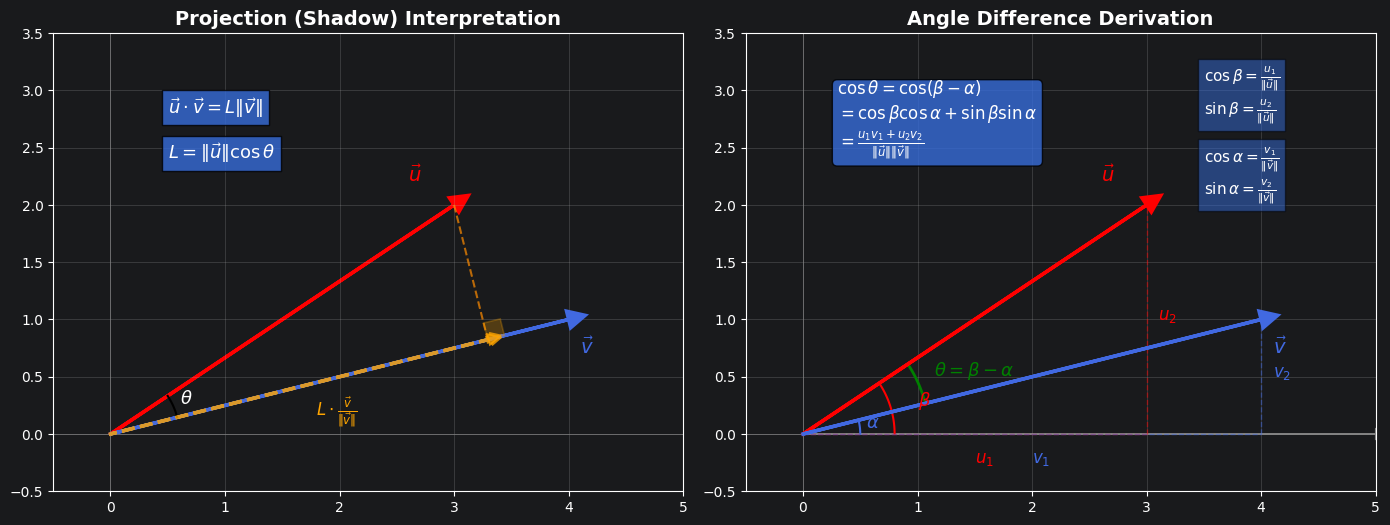

In [76]:
# plt practice

u = np.array([3.0, 2.0])
v = np.array([4.0, 1.0])

dot_product = np.dot(u, v)

norm_u = np.linalg.norm(u)
norm_v = np.linalg.norm(v)

alpha = np.arctan2(v[1], v[0])  # angle of v
beta = np.arctan2(u[1], u[0])   # angle of u

L = dot_product / norm_v
proj_u_on_v = L * (v / norm_v) # L (scalar) in the direction of v: vector

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1 = axes[0]
ax1.set_xlim(-0.5, 5)
ax1.set_ylim(-0.5, 3.5)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linewidth=0.5)
ax1.axvline(x=0, color='gray', linewidth=0.5)

# --- LEFT SUBPLOT: SHADOW ---

# vector v (the RHS vector that receives the shadow)
ax1.arrow(0, 0, v[0], v[1], head_width=0.15, head_length=0.15,
          fc='royalblue', ec='royalblue', linewidth=2.5, zorder=2)
ax1.text(v[0] + 0.1, v[1] - 0.3, r'$\vec{v}$', fontsize=14, color='royalblue')

# vector u (the vector casting the shadow)
ax1.arrow(0, 0, u[0], u[1], head_width=0.15, head_length=0.15,
          fc='red', ec='red', linewidth=2.5, zorder=1)
ax1.text(u[0] - 0.4, u[1] + 0.2, r'$\vec{u}$', fontsize=14, color='red')

# the projection of u onto v (the shadow)
ax1.arrow(0, 0, proj_u_on_v[0], proj_u_on_v[1], head_width=0.12, head_length=0.12,
          fc='orange', ec='orange', linewidth=2.5, alpha=0.8, zorder=3,
          linestyle='--')
mid_proj = proj_u_on_v / 2
ax1.text(mid_proj[0] + 0.15, mid_proj[1] - 0.25, r'$L \cdot \frac{\vec{v}}{\|\vec{v}\|}$',
         fontsize=12, color='orange')

# tip of u drops to projection
tip_u = u
perp = tip_u - proj_u_on_v  # component of u perpendicular to v
ax1.plot([tip_u[0], proj_u_on_v[0]], [tip_u[1], proj_u_on_v[1]],
         '--', color='darkorange', linewidth=1.5, alpha=0.7)

# mark the right angle
v_dir = v / norm_v           # unit vector along v
perp_dir = perp / np.linalg.norm(perp)  # unit vector perpendicular to v
square_size = 0.15

square_pts = np.array([
    proj_u_on_v,
    proj_u_on_v + square_size * v_dir,
    proj_u_on_v + square_size * v_dir + square_size * perp_dir,
    proj_u_on_v + square_size * perp_dir
])

ax1.fill(square_pts[:, 0], square_pts[:, 1],
        facecolor='orange', edgecolor='orange',
        alpha=0.25, linewidth=1.2, zorder=4)

# craw angle theta arc
arc_radius = 0.6
arc_theta = np.linspace(alpha, beta, 50)
ax1.plot(arc_radius * np.cos(arc_theta), arc_radius * np.sin(arc_theta),
         'k-', linewidth=1.5)
mid_angle = (alpha + beta) / 2
ax1.text(1.1 * arc_radius * np.cos(mid_angle), 1.1 * arc_radius * np.sin(mid_angle),
         r'$\theta$', fontsize=13)

ax1.annotate(
    r'$\vec{u} \cdot \vec{v} = L\|\vec{v}\|$',
    xy=(0.5, 2.8), fontsize=13,
    bbox=dict(alpha=0.8))
ax1.annotate(
    r'$L = \|\vec{u}\|\cos\theta$',
    xy=(0.5, 2.4), fontsize=13,
    bbox=dict(alpha=0.8))

ax1.set_title('Projection (Shadow) Interpretation', fontsize=14, fontweight='bold')

# --- RIGHT SUBPLOT: ANGLES ---

ax2 = axes[1]
ax2.set_xlim(-0.5, 5)
ax2.set_ylim(-0.5, 3.5)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.axvline(x=0, color='gray', linewidth=0.5)

# draw x-axis
ax2.arrow(0, 0, 5, 0, head_width=0.1, head_length=0.1, fc='gray', ec='gray', linewidth=1)

# vector u
ax2.arrow(0, 0, u[0], u[1], head_width=0.15, head_length=0.15,
          fc='red', ec='red', linewidth=2.5, zorder=3)
ax2.text(u[0] - 0.4, u[1] + 0.2, r'$\vec{u}$', fontsize=14, color='red')

# vector v
ax2.arrow(0, 0, v[0], v[1], head_width=0.15, head_length=0.15,
          fc='royalblue', ec='royalblue', linewidth=2.5, zorder=3)
ax2.text(v[0] + 0.1, v[1] - 0.3, r'$\vec{v}$', fontsize=14, color='royalblue')

# angle beta (u with x-axis)
arc_beta = np.linspace(0, beta, 50)
ax2.plot(0.8 * np.cos(arc_beta), 0.8 * np.sin(arc_beta), color='red', linewidth=1.5)
ax2.text(1.0, 0.25, r'$\beta$', fontsize=13, color='red')

# angle alpha (v with x-axis)
arc_alpha = np.linspace(0, alpha, 50)
ax2.plot(0.5 * np.cos(arc_alpha), 0.5 * np.sin(arc_alpha), color='royalblue', linewidth=1.5)
ax2.text(0.55, 0.05, r'$\alpha$', fontsize=13, color='royalblue')

# Draw angle theta = beta - alpha
arc_theta = np.linspace(alpha, beta, 50)
ax2.plot(1.1 * np.cos(arc_theta), 1.1 * np.sin(arc_theta), color='green', linewidth=2)
mid_theta = (alpha + beta) / 2
ax2.text(1.25 * np.cos(mid_theta), 1.25 * np.sin(mid_theta),
         r'$\theta = \beta - \alpha$', color='green', fontsize=13)

# components of u
# u1 (horizontal)
ax2.plot([0, u[0]], [0, 0], '--', color='red', alpha=0.5, linewidth=1)
ax2.text(u[0]/2, -0.25, r'$u_1$', fontsize=12, color='red')
# u2 (vertical)
ax2.plot([u[0], u[0]], [0, u[1]], '--', color='red', alpha=0.5, linewidth=1)
ax2.text(u[0] + 0.1, u[1]/2, r'$u_2$', fontsize=12, color='red')

# components of v
# v1 (horizontal)
ax2.plot([0, v[0]], [0, 0], '--', color='royalblue', alpha=0.5, linewidth=1)
ax2.text(v[0]/2, -0.25, r'$v_1$', fontsize=12, color='royalblue')
# v2 (vertical)
ax2.plot([v[0], v[0]], [0, v[1]], '--', color='royalblue', alpha=0.5, linewidth=1)
ax2.text(v[0] + 0.1, v[1]/2, r'$v_2$', fontsize=12, color='royalblue')

# annotations
ax2.annotate(
    r'$\cos\beta = \frac{u_1}{\|\vec{u}\|}$' + '\n' +
    r'$\sin\beta = \frac{u_2}{\|\vec{u}\|}$',
    xy=(3.5, 2.8), fontsize=11,
    bbox=dict(alpha=0.5),
)

ax2.annotate(
    r'$\cos\alpha = \frac{v_1}{\|\vec{v}\|}$' + '\n' +
    r'$\sin\alpha = \frac{v_2}{\|\vec{v}\|}$',
    xy=(3.5, 2.1), fontsize=11,
    bbox=dict(alpha=0.5)
)

ax2.annotate(
    r'$\cos\theta = \cos(\beta - \alpha)$' + '\n' +
    r'$= \cos\beta\cos\alpha + \sin\beta\sin\alpha$' + '\n' +
    r'$= \frac{u_1 v_1 + u_2 v_2}{\|\vec{u}\|\|\vec{v}\|}$',
    xy=(0.3, 2.5), fontsize=12,
    bbox=dict(boxstyle='round,pad=0.3', alpha=0.8))

ax2.set_title('Angle Difference Derivation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### 1.1 Dot Product in Attention

In [10]:
# dot product in attention
d_k = 64

# two random vectors in high dimensions
q = torch.randn(d_k)
k = torch.randn(d_k)

# unscaled dot product can be quite large
raw = torch.dot(q, k)
print(f"Raw dot product: {raw:.2f}")

# scaled: divide by sqrt(d_k)
scaled = raw / (d_k ** 0.5)
print(f"Scaled: {scaled:.2f}")

Raw dot product: 7.19
Scaled: 0.90


In self-attention, `Q @ K^T` computes the dot product between every query and every key, measuring relevance.

But attention needs a probability distribution over tokens -- every value between 0 and 1, all summing to 1. Softmax does this by amplifying the largest values and suppressing the rest.

`sqrt(d_k)` scaling factor in attention exists because of this dot product interpretation: as `d_k` (the key/query dimension) grows, the variance of the dot product grows proportionally, pushing the softmax into regions with extremely small gradients.

For a vector $z = [z_1, z_2, \dots, z_n]$:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}$$

In [4]:
# softmax quick test

# raw attention scores for one query attending to 4 keys
scores = torch.tensor([2.0, 1.0, -3.0, 0.5])

exp_scores = torch.exp(scores)
print("exponentiated:", exp_scores)
print("sum:", exp_scores.sum())

softmax_manual = exp_scores / exp_scores.sum()
print("manual softmax:", softmax_manual)

# PyTorch version
softmax_torch = F.softmax(scores, dim=-1)
print("PyTorch softmax:", softmax_torch)

exponentiated: tensor([7.3891, 2.7183, 0.0498, 1.6487])
sum: tensor(11.8058)
manual softmax: tensor([0.6259, 0.2302, 0.0042, 0.1397])
PyTorch softmax: tensor([0.6259, 0.2302, 0.0042, 0.1397])


* Exponentiation creates positivity. No matter how negative the input, `e^z > 0`. No matter how positive, `e^z < ∞`.
* The denominator normalizes. Dividing by the sum forces all outputs to sum to 1.

In [14]:
scores_moderate = torch.tensor([2.0, 1.0, -3.0, 0.5])
scores_extreme  = torch.tensor([20.0, 10.0, -30.0, 5.0])  # x10 shift

print("Moderate scores:", F.softmax(scores_moderate, dim=-1))
print("Extreme scores: ", F.softmax(scores_extreme, dim=-1))

Moderate scores: tensor([0.6259, 0.2302, 0.0042, 0.1397])
Extreme scores:  tensor([9.9995e-01, 4.5398e-05, 1.9287e-22, 3.0589e-07])


* The scores have the same relative ordering, but the softmax output on extreme values is more peaked -- it concentrates probability mass on the winner.

In [11]:
# simulate Q @ K^T for one query against 4 keys
torch.manual_seed(123)
scores = torch.randn(4) * math.sqrt(d_k)  # variance ~ d_k
print("Unscaled scores:", scores)
print("Unscaled softmax:", F.softmax(scores, dim=-1))

# scale down
scores_scaled = scores / math.sqrt(d_k)
print("\nScaled scores:", scores_scaled)
print("Scaled softmax:", F.softmax(scores_scaled, dim=-1))

Unscaled scores: tensor([-0.8917,  0.9629, -2.9571, -1.9233])
Unscaled softmax: tensor([0.1270, 0.8116, 0.0161, 0.0453])

Scaled scores: tensor([-0.1115,  0.1204, -0.3696, -0.2404])
Scaled softmax: tensor([0.2556, 0.3223, 0.1974, 0.2247])


* Without scaling, one token hogs 81% of attention. The model can't learn nuanced patterns when every attention head collapses to a near one-hot vector. With scaling, the distribution stays softer, and gradients flow to all positions.

### 2. Matrix Multiplication

In [78]:
A = torch.randn(3, 4)
B = torch.randn(4, 2)
C = A @ B

print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")
print(f"C shape: {C.shape}")

A shape: torch.Size([3, 4])
B shape: torch.Size([4, 2])
C shape: torch.Size([3, 2])


In [81]:
# view: each entry C[i, j] is the dot product of row i of A with column j of B
manual_entry = torch.dot(A[1, :], B[:, 0])
print(f"C[1, 0] from matmul: {C[1, 0]:.6f}")
print(f"dot(A[1,:], B[:,0]): {manual_entry:.6f}")

C[1, 0] from matmul: -1.127403
dot(A[1,:], B[:,0]): -1.127403


In [83]:
# view: each column of C is a weighted sum of columns of A, with weights from the corresponding column of B
reconstructed_col0 = torch.zeros(3)
for k in range(4):  # for each column of A
    reconstructed_col0 += B[k, 0] * A[:, k]

print(f"Original C[:, 0]:      {C[:, 0]}")
print(f"Reconstructed C[:, 0]: {reconstructed_col0}")

Original C[:, 0]:      tensor([ 0.7455, -1.1274,  0.8812])
Reconstructed C[:, 0]: tensor([ 0.7455, -1.1274,  0.8812])


In [87]:
# matrix multiplication as a transformation
theta = np.pi / 4  # 45 degrees
rotation = torch.tensor([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
], dtype=torch.float32)

x = torch.tensor([1.0, 0.0])
rotated = rotation @ x

print(f"Original: {x}")
print(f"Rotated:  {rotated}")

Original: tensor([1., 0.])
Rotated:  tensor([0.7071, 0.7071])


A transformation (or function or mapping) T from ℝⁿ to ℝᵐ is a rule that assigns to each vector $\vec x$ in ℝⁿ to a vector T(x) in ℝᵐ

T is **linear** if it satisfies two properties:
1. T(x + y) = T(x) + T(y) -- preserves addition
2. T(c·x) = c·T(x) -- preserves scalar multiplication.

Every linear transformation (rotation, scaling, projection, reflection, shearing) can be expressed as a matrix multiplication.
> If T is any linear transformation from ℝⁿ to ℝᵐ, there exists a matrix A such that T(x) = A @ x for all x.

#### 2.1 In Transformers

Every weight matrix in a transformer is a learned linear transformation:
* **W_Q, W_K, W_V**: project token representation into query, key, and value spaces
* **W_O**: project the concatenated attention output back to model dimension
* **FFN matrices**: transform representations within each token position

For example, `W_Q @ x` applies a learned transformation that rotates and scales the token's representation into "query space" -- a space optimized for computing similarity with key vectors.

The operation `attn_weights @ V` is also a linear transformation. Each output row is a weighted combination (linear combination) of the value vectors, with the attention weights providing the mixing coefficients.

In [10]:
# single-head attention

Q = torch.tensor([
    [1.0, 0.0, 1.0],   # token 0 query
    [0.0, 1.0, 1.0]    # token 1 query
])
print("Q:\n", Q)
print("  Row 0 = query vector for token 0:", Q[0])
print("  Row 1 = query vector for token 1:", Q[1])

K = torch.tensor([
    [1.0, 0.0, 1.0],   # token 0 key
    [0.0, 1.0, 1.0]    # token 1 key
])
print("K:\n", K)
print("  Row 0 = key vector for token 0:", K[0])
print("  Row 1 = key vector for token 1:", K[1])

# transpose K to make columns into rows
K_T = K.transpose(-2, -1)

print("K^T:\n", K_T)
print("  Column 0 = key vector for token 0:", K_T[:, 0])
print("  Column 1 = key vector for token 1:", K_T[:, 1])

#  scores[i, j] = dot product of Q[i] (row) with K.T[:, j] (column)
#               = dot product of query i with key j
#               = "how much should token i attend to token j?"
scores = Q @ K_T
print("Scores:\n", scores)

Q:
 tensor([[1., 0., 1.],
        [0., 1., 1.]])
  Row 0 = query vector for token 0: tensor([1., 0., 1.])
  Row 1 = query vector for token 1: tensor([0., 1., 1.])
K:
 tensor([[1., 0., 1.],
        [0., 1., 1.]])
  Row 0 = key vector for token 0: tensor([1., 0., 1.])
  Row 1 = key vector for token 1: tensor([0., 1., 1.])
K^T:
 tensor([[1., 0.],
        [0., 1.],
        [1., 1.]])
  Column 0 = key vector for token 0: tensor([1., 0., 1.])
  Column 1 = key vector for token 1: tensor([0., 1., 1.])
Scores:
 tensor([[2., 1.],
        [1., 2.]])


In [19]:
# after softmax, we get attention weights, then compute context via:
attn = torch.tensor([
    [0.7, 0.3],   # token 0 attends 70% to token 0, 30% to token 1
    [0.3, 0.7]    # token 1 attends 30% to token 0, 70% to token 1
])  # Shape: (2, 2)

V = torch.tensor([
    [1.0, 2.0, 3.0],   # value for token 0
    [4.0, 5.0, 6.0]    # value for token 1
])  # Shape: (2, 3)

output = attn @ V  # (2, 2) @ (2, 3) -> (2, 3)

print("\nToken 0 is a weighted blend of all value vectors:")
print(f"  attn[0][0] * V[0] + attn[0][1] * V[1]")
print(f"  = {attn[0, 0]:.1f} * {V[0].tolist()} + {attn[0, 1]:.1f} * {V[1].tolist()}")
print(f"  = {[round(v, 2) for v in output[0].tolist()]}")


Token 0 is a weighted blend of all value vectors:
  attn[0][0] * V[0] + attn[0][1] * V[1]
  = 0.7 * [1.0, 2.0, 3.0] + 0.3 * [4.0, 5.0, 6.0]
  = [1.9, 2.9, 3.9]


In [34]:
# feedforward network: x (d_model) → Linear(d_model, d_ff) → non-linear activation function → Linear(d_ff, d_model) → output (d_model)

d_model = 2  # model dimension, small for visibility
d_ff = 3     # feed-forward hidden dimension (usually 4x d_model)

# a token vector (after attention + residual + layer norm)
x = torch.tensor([0.8, 0.5])
print(f"Input token x: {x}")

W1 = torch.tensor([
    [ 1.5,  0.0],   # row 0: scale x_1 by 1.5, ignore x_2
    [ 0.0, -0.8],   # row 1: ignore x_1, scale and flip x_2
    [ 1.0,  1.0]    # row 2: sum x_1 and x_2
])
print(f"W1 shape `(d_ff, d_model) -- (output_dim, input_dim)`: {W1.shape}")

# the transformation
h_pre_act = W1 @ x         # (3, 2) @ (2,) → (3,)
h = torch.relu(h_pre_act)  # ReLU zeros out negative values
print(f"\nW₁ @ x:        {h_pre_act}")
print(f"After ReLU:    {h}")

# second linear transformation
W2 = torch.tensor([
    [ 0.5, -0.3,  0.8],   # row 0: weighted combination of h's dimensions → output dim 0
    [ 0.2,  0.7, -0.4]    # row 1: weighted combination of h's dimensions → output dim 1
])
output = W2 @ h           # (2, 3) @ (3,) → (2,)
print(f"\nW₂ shape:      {W2.shape}")   # (d_model, d_ff) = (2, 3)
print(f"W₂ @ h:        {output}")
print(f"Output shape:  {output.shape}") # (2,) -- back to d_model

Input token x: tensor([0.8000, 0.5000])
W1 shape `(d_ff, d_model) -- (output_dim, input_dim)`: torch.Size([3, 2])

W₁ @ x:        tensor([ 1.2000, -0.4000,  1.3000])
After ReLU:    tensor([1.2000, 0.0000, 1.3000])

W₂ shape:      torch.Size([2, 3])
W₂ @ h:        tensor([ 1.6400, -0.2800])
Output shape:  torch.Size([2])


* In transformers' feed forward network, $W_1$ and $W_2$ are learned matrices--randomly initialized then specialized through gradient descent during training.
* The former expands input x to give the model more dimensions (typically 4x) to work with -- more feature detectors, each asking how much does the input align with this learned direction.
* A nonlinear activation function between $W_1$ and $W_2$ breaks the chain of linear operations. Without it, `W_2 @ (W_1 @ x)` would collapse into `(W_2 @ W_1) @ x` -- a single matrix -- making the expansion pointless. This nonlinearity breaks the chain, giving the FFN the capacity to learn complex, non-linear transformations.
* The latter contracts back to the original size so the output can be added via residual connection.

#### 2.2 In Tandem with Other Operations

In [42]:
# activation functions

x = torch.tensor([-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0])
print(f"Input: {x}")

# Rectified Linear Unit: ReLU(x) = max(0, x), original transformer
relu_out = F.relu(x)
print(f"ReLU:  {relu_out}")

# Gaussian Error Linear Unit: GELU(x) ≈ x ⋅ Φ(x), vision transformers
# where Φ(x) is the cumulative distribution function of the standard normal
gelu_out = F.gelu(x)
print(f"GELU:  {gelu_out}")

# Swish-Gated Linear Unit: SwiGLU(x) = linear(x) ⋅ sigmoid(gate(x))
swish = lambda x: x * torch.sigmoid(x)
swish_out = swish(x)
print(f"Swish: {swish_out}")

Input: tensor([-2.0000, -1.0000, -0.5000,  0.0000,  0.5000,  1.0000,  2.0000])
ReLU:  tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 1.0000, 2.0000])
GELU:  tensor([-0.0455, -0.1587, -0.1543,  0.0000,  0.3457,  0.8413,  1.9545])
Swish: tensor([-0.2384, -0.2689, -0.1888,  0.0000,  0.3112,  0.7311,  1.7616])


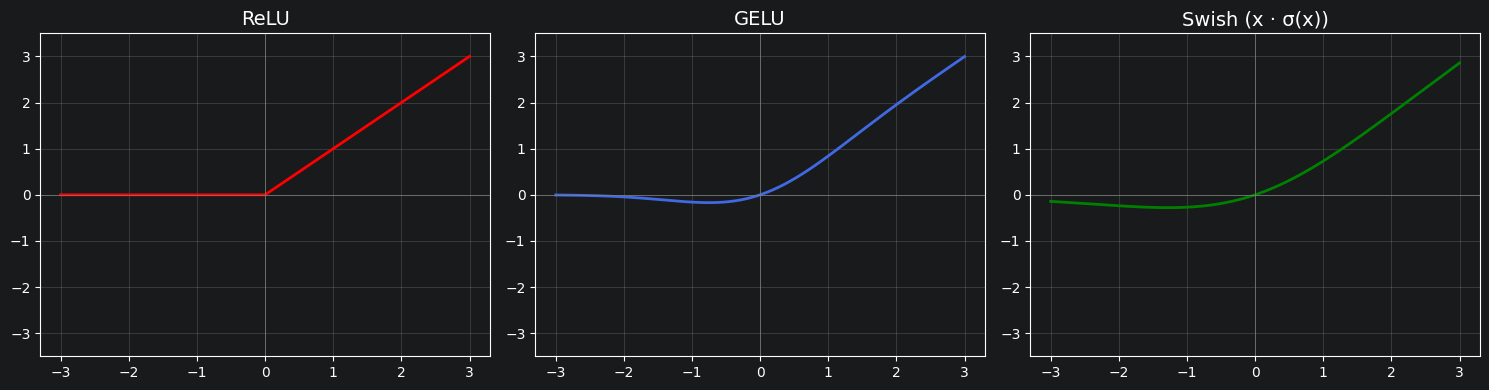

In [45]:
x_plot = torch.linspace(-3, 3, 300)

activations = [
    ('ReLU',              lambda x: F.relu(x),              'red'),
    ('GELU',              lambda x: F.gelu(x),              'royalblue'),
    ('Swish (x · σ(x))',  lambda x: x * torch.sigmoid(x),   'green'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, fn, color) in zip(axes, activations):
    ax.plot(x_plot, fn(x_plot), linewidth=2, color=color)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(name, fontsize=14)
    ax.set_ylim(-3.5, 3.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# transpose

In [ ]:
# broadcasting

In [ ]:
# + bias

In [ ]:
# 2d vs 3c vs 4d vs nd

A matrix multiplication computes many dot products simultaneously. When the transformer computes `Q @ K^T`, it's computing `seq_len²` dot products in one operation. But transformers don't process one sequence at a time — they process a batch of sequences, and often with multiple attention heads. On a GPU, this all happens in parallel.

In [88]:
# matrix multiplication in batches
batch_size, num_heads, seq_len, d_k = 2, 2, 4, 3

Q = torch.randn(batch_size, num_heads, seq_len, d_k)
K = torch.randn(batch_size, num_heads, seq_len, d_k)

scores = Q @ K.transpose(-2, -1)

print(f"Q shape:            {Q.shape}")
print(f"K.T shape:          {K.transpose(-2, -1).shape}")
print(f"Scores shape:       {scores.shape}")
print(f"Total dot products: {batch_size * num_heads * seq_len * seq_len}")
print()

# each slice is an independent attention score matrix
print("Batch 0, Head 0 scores:\n", scores[0, 0])
print("\nBatch 0, Head 1 scores:\n", scores[0, 1])
print("\nBatch 1, Head 0 scores:\n", scores[1, 0])

Q shape:            torch.Size([2, 2, 4, 3])
K.T shape:          torch.Size([2, 2, 3, 4])
Scores shape:       torch.Size([2, 2, 4, 4])
Total dot products: 64

Batch 0, Head 0 scores:
 tensor([[-2.4462, -0.6546, -0.2542,  2.9561],
        [ 2.7453,  3.3335, -3.6862, -1.0917],
        [ 1.0481,  0.8711, -0.8208, -0.6644],
        [ 2.4383,  1.7519, -1.3687, -2.2104]])

Batch 0, Head 1 scores:
 tensor([[-3.5663e-01, -4.1731e+00,  9.7799e-01, -1.7813e+00],
        [-3.9843e-03,  1.5933e+00,  8.2449e-01, -1.9418e-01],
        [-8.3778e-01,  1.9448e+00, -4.2208e+00,  1.6922e+00],
        [-7.0702e-01, -5.5873e-01, -2.2872e+00,  2.9632e-01]])

Batch 1, Head 0 scores:
 tensor([[ 1.4696,  0.6459,  1.2199,  0.9130],
        [-0.0489,  1.0409, -1.2019,  2.1493],
        [ 0.6464,  2.5803, -0.6899,  1.4838],
        [-1.3371, -0.6851, -0.6219, -2.1092]])


In [ ]:
# broadcasting -> residuals

In [ ]:
# Symmetry for layer norm

In [ ]:
# linear independence, why multiple heads aren't redundant

In [ ]:
# rank, what limits a model's expressiveness

In [ ]:
# tensors, tensor shapes

In [ ]:
# symmetry, eigenvalues/eigenvectors

## Calculus

**Fundamental Theorem of Calculus**:
$$\int_a^b f'(x) \, dx = f(b) - f(a)$$
> the integral of a differential form is evaluated on the boundary
---

**Fundamental Theorem for Line Integrals**:

$$\int_C \nabla f \cdot \hat{t} \, ds = f(\vec{r}(b)) - f(\vec{r}(a))$$

Or in components:

$$\int_{(a_1, a_2)}^{(b_1, b_2)} f_{x} \, dx + f_{y} \, dy  = f(b_1, b_2) - f(a_1, a_2)$$

Where:
- $C$ is a curve from $\vec{r}(a)$ to $\vec{r}(b)$
- $\nabla f = <f_{x}, f_{y}>$ is the gradient of $F$ (partial derivatives of $F$)
- $\hat{t}$ is the unit tangent vector along $C$

---

**Green's Theorem (Tangential/Circulation Form)**
$$\iint_D \nabla x \vec{F} \cdot \hat{k} \, dA = \oint_{\partial D} \vec{F} \cdot \hat{t} ds $$

Where
- $D$ = region in the plane
- $\partial D$ = boundary of $D$ (closed curve)
- $\hat{k}$ = unit vector perpendicular to the plane
- $ds$ = arc length element
- $\nabla \times \vec{F} = \frac{\partial F_y}{\partial x} - \frac{\partial F_x}{\partial y}$ (scalar curl)

---

**Green's Theorem (Normal/Flux Form)**
$$\iint_D \nabla \cdot \vec{F} \, dA = \oint_{\partial D} \vec{F} \cdot \hat{n} \, ds$$
Where:
- $\hat{n}$ = outward unit normal vector
- $\nabla \cdot \vec{F} = \frac{\partial F_x}{\partial x} + \frac{\partial F_y}{\partial y}$ (divergence of $\vec{F}$)
<br> The total divergence (source strength) inside $D$ equals the net flux outward through its boundary. *Divergence Theorem one dimension down*.

---

**Stokes Theorem**
$$\iint_S (\nabla \times \vec{F}) \cdot \hat{n} \, dS = \oint_{\partial S} \vec{F} \cdot d\vec{r}$$
Where:
- $S$ is an oriented surface in $\mathbb{R}^3$
- $\partial S$ is the closed curve bounding $S$
- $\hat{n}$ is the unit normal vector
- $dS$ is the surface area element
- $d\vec{r} = \hat{t} \, ds$
<br> The circulation of $\vec{F}$ around $\partial S$ equals the total curl (rotation) through $S$.

---

**Divergence Theorem (Gauss's Theorem)**

$$\iiint_E \nabla \cdot \vec{F} \, dV = \iint_{\partial E} \vec{F} \cdot \hat{n} \, dS$$
Where:
- $E$ is a solid in $\mathbb{R}^3$
- $\partial E$ is the closed surface bounding $V$
- $\hat{n}$ is the outward unit normal vector
- $dS$ is the surface area element
<br> The total divergence (source strength) inside $V$ equals the net flux outward through its boundary.

In [ ]:
# chain rule

In [ ]:
# gradient descent

In [ ]:
# backpropagation

In [ ]:
# universal approximation

## Other

In [ ]:
# Jacobian

In [ ]:
# differential equations